# 05 · Benchmark comparison

Two head-to-heads:

- **Benchmark A — polynomial ODE (Lotka–Volterra):** noise robustness, vanilla vs. weak SINDy.
- **Benchmark B — Michaelis–Menten (a DAE with rational structure):** which methods can even
  *represent* the dynamics — vanilla SINDy, SINDy-PI, or SODAs? All use the **same** MM system
  ($k=k_r=k_{cat}=1,\ E_0=1 \Rightarrow V_{\max}=1,\ K_m=2$).

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Benchmark A — noise robustness on Lotka–Volterra

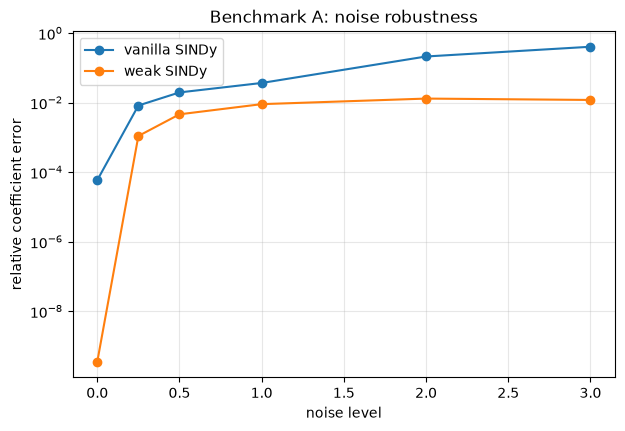

In [3]:
from sparse_demos import systems, metrics, plotting
import pysindy as ps

def lv_rel_error(model):
    names, C = model.get_feature_names(), model.coefficients()
    g = lambda n: C[:, names.index(n)] if n in names else np.zeros(C.shape[0])
    est = np.array([g("x")[0], g("x y")[0], g("y")[1], g("x y")[1]])
    return metrics.coef_l2_error(np.array([1.0, -0.1, -1.5, 0.075]), est)

noise_levels = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]
errs = {"vanilla SINDy": [], "weak SINDy": []}
for nz in noise_levels:
    tt, XX = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01, noise_std=nz, seed=11)
    ddt = tt[1] - tt[0]
    v = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2), optimizer=ps.STLSQ(threshold=0.05))
    v.fit(XX, t=ddt, feature_names=["x", "y"])
    wl = ps.WeakPDELibrary(function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
                           spatiotemporal_grid=tt, is_uniform=True, K=200)
    w = ps.SINDy(feature_library=wl, optimizer=ps.STLSQ(threshold=0.05))
    w.fit(XX, t=ddt, feature_names=["x", "y"])
    errs["vanilla SINDy"].append(lv_rel_error(v))
    errs["weak SINDy"].append(lv_rel_error(w))

plotting.plot_noise_sweep(noise_levels, errs, title="Benchmark A: noise robustness")
plt.show()

## Benchmark B — Michaelis–Menten (rational / DAE)

**Vanilla SINDy** and **SINDy-PI** see the reduced substrate law $\dot S = -S/(2+S)$;
**SODAs** sees the full four-species DAE.

In [4]:
# --- reduced rational substrate data for the ODE-style methods ---
t, Xr = systems.simulate_mm(t_span=(0, 12), dt=0.02, s0=4.0, vmax=1.0, km=2.0)
S = Xr[:, :1]; dt = t[1] - t[0]

van = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=ps.STLSQ(threshold=0.01))
van.fit(S, t=dt, feature_names=["S"])

pde = ps.PDELibrary(function_library=ps.PolynomialLibrary(degree=1, include_bias=False),
                    derivative_order=1, temporal_grid=t, implicit_terms=True, include_bias=True)
pi = ps.SINDy(feature_library=pde,
              optimizer=ps.SINDyPI(reg_weight_lam=1e-4, regularizer="l1", tol=1e-12,
                                   max_iter=30000, normalize_columns=False, model_subset=[1, 2, 3]))
pi.fit(S, t=dt, feature_names=["S"])

print("--- Vanilla SINDy (polynomial library): wrong functional form ---")
van.print()
print("\n--- SINDy-PI (implicit): read the (S) = ... row  ->  (2+S) dS/dt = -S ---")
pi.print(precision=3)

Model  1


Model  2
Model  3


--- Vanilla SINDy (polynomial library): wrong functional form ---
(S)' = -0.011 1 + -0.421 S +  0.111 S^2 + -0.012 S^3

--- SINDy-PI (implicit): read the (S) = ... row  ->  (2+S) dS/dt = -S ---
(1) =  0.000
(S) = -2.000 S_t + -1.000 SS_t
(S_t) = -0.500 S + -0.500 SS_t
(SS_t) = -1.000 S + -2.000 S_t


In [5]:
# --- SODAs on the full DAE (multi-IC enzyme assay) ---
import pandas as pd
from sklearn.linear_model import LinearRegression
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix, AlgModelFinder,
                       sequentialThLin, get_refined_lib)
import sympy

k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0}); species = ["[S]", "[E]", "[ES]", "[P]"]
tg = np.linspace(0, 4, 40)
sl = []
for S0 in [1.0, 2.0, 3.0, 4.0, 5.0]:
    df = pd.DataFrame(solveMM(pd.Series({"S": S0, "P": 0.0, "E": 1.0}), k_rates, tg, "b"), columns=species)
    df["[t]"] = tg
    sl.append(smooth_data(df, domain_var="[t]", derr_order=1, noise_perc=0, eval_points=tg))
smooth_app = pd.concat(sl, ignore_index=True); state = smooth_app[species]
Ssym, Esym, ESsym, Psym = sympy.symbols(list(state.columns))
lib = PolyFeatureMatrix(degree=3).fit_transform(state).drop(["1"], axis=1)

cons = LinearRegression().fit(state[["[ES]"]], state["[E]"])
qssa = LinearRegression(fit_intercept=False).fit(lib[["[S] [E]"]], lib["[ES]"])
_, refined_dyn = get_refined_lib({Esym, Ssym * ESsym}, state, lib, get_dropped_feat=True)
dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
dyn.fit(X=refined_dyn, y=smooth_app["d([P]) /dt"])
dterms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_) if abs(c) > 1e-2}

print("--- SODAs (DaeFinder): full DAE ---")
print("  enzyme conservation : [E] + [ES] = %.3f" % cons.intercept_)
print("  QSSA (steady state) : [ES] = %.3f [S][E]   (<=> [S][E] = 2[ES])" % qssa.coef_[0])
print("  dynamics            : d[P]/dt = %s ,  d[S]/dt = -[ES]" % dterms)

Sequential threshold converged in 1 iterations
--- SODAs (DaeFinder): full DAE ---
  enzyme conservation : [E] + [ES] = 1.000
  QSSA (steady state) : [ES] = 0.500 [S][E]   (<=> [S][E] = 2[ES])
  dynamics            : d[P]/dt = {'[ES]': 1.0} ,  d[S]/dt = -[ES]


## Summary

| Method | Derivatives | Data type | Noise robustness | Rational / implicit | Algebraic (DAE) |
|---|---|---|---|---|---|
| **Vanilla SINDy** | pointwise (fragile) | ODE | low | ✗ | ✗ |
| **Weak SINDy** | integral / weak | ODE/PDE | **high** | ✗ | ✗ |
| **SINDy-PI** | implicit | ODE | medium | **✓** | partial |
| **SODAs** | smoothed + staged | **DAE** | medium–high | ✓ (as reduced ODE) | **✓** |

**Conclusions**

- On clean polynomial ODEs, vanilla SINDy is simplest and exact.
- Under heavy noise, switch to the **weak form**.
- For **rational/implicit** dynamics, polynomial SINDy is structurally wrong; **SINDy-PI**
  recovers the implicit law $\dot S = -S/(2+S)$.
- For genuine **differential–algebraic** systems, **SODAs** discovers the conservation and
  steady-state relations *and* the dynamics — and those algebraic relations reduce exactly to
  the SINDy-PI rational ODE, so the two views agree.

*No single method is best — the right choice follows from your data (noise) and model class
(polynomial / rational / constrained).*